<a href="https://colab.research.google.com/github/flash-berry/MachineLearning-2025/blob/main/HM_1_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ДЗ#1
1. Найти на kaggle соревнования по классификации, регрессии, кластеризации. Для каждого написать решение с использованием всех разобранных на занятии моделей с дефолтными гиперпараметрами.
2. Реализовать product quantization самостоятельно и посчитать ошибку представления на 2 датасетах:
- сгенерированом так, чтобы в каждом под-пространстве вектора хорошо кластеризовались (центр + белый шум)
- эмбеддингах любого датасета от любой нейронки

**Выполнил студент магистратуры ИИНОД Пышный Артём Александрович**

In [ ]:
!pip install gdown

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import silhouette_score

import gdown
import math
import os
import zipfile
import urllib.request

# Classification on titanic dataset

**Подготавливаем данные https://www.kaggle.com/competitions/titanic**

Описание датасета:

PassengerId ––– id пассажира, можно взять за индекс

Survived (целевой признак) ––– выжил ли пассажир (0 = Нет, 1 = Да);

Pclass ––– класс билета (1 = 1st, 2 = 2nd, 3 = 3rd);

Sex ––– пол (female или male)

Age ––– возраст в годах

SibSp ––– количество братьев, сестёр (в том числе сводных) и супругов на борту

Parch ––– количество детей и родителей на борту

Ticket ––– номер билета

Fare ––– стоимость проезда пассажира

Cabin ––– номер каюты

Embarked ––– порт посадки пассажира (C = Cherbourg, Q = Queenstown, S = Southampton).

In [ ]:
url = "https://drive.google.com/file/d/1CzVPf53C45Ew9xp5CE3eONWYiIJXJlG2/view?usp=sharing"

file_id = url.split("/d/")[1].split("/")[0]
download_url = f"https://drive.google.com/uc?id={file_id}"
output = 'train_titanic.csv'

gdown.download(download_url, output, quiet=False)

df = pd.read_csv('train_titanic.csv')

Downloading...
From: https://drive.google.com/uc?id=1CzVPf53C45Ew9xp5CE3eONWYiIJXJlG2
To: /content/train_titanic.csv
100%|██████████| 61.2k/61.2k [00:00<00:00, 19.3MB/s]


In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [ ]:
df.fillna({'Embarked': 'S'}, inplace=True)

In [ ]:
df.loc[:, 'Sex'] = df['Sex'].map({'male': 0, 'female': 1}).astype('int64')
df.loc[:, 'Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2}).astype('int64')

df = df.drop(['Name', 'Ticket', 'Cabin', 'PassengerId'], axis=1)

df = df.dropna()

In [ ]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0


In [ ]:
y = df[["Survived"]].values.ravel()
X = df.drop(columns=["Survived"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Алгоритм SVM**

In [ ]:
svm = SVC(random_state=42)
svm.fit(X_train_scaled, y_train)
print("train accuracy: ", svm.score(X_train_scaled, y_train))
print("test accuracy: ", svm.score(X_test_scaled, y_test))

train accuracy:  0.8617234468937875
test accuracy:  0.813953488372093


**Логистическая регрессия**

In [ ]:
logreg = LogisticRegression(random_state=42)
logreg.fit(X_train_scaled, y_train)
print("train accuracy: ", logreg.score(X_train_scaled, y_train))
print("test accuracy: ", logreg.score(X_test_scaled, y_test))

train accuracy:  0.8096192384769539
test accuracy:  0.7767441860465116


**Решающие деревья классификатор**

In [ ]:
decision_tree = DecisionTreeClassifier()
decision_tree.fit(X_train, y_train)
print("train accuracy:", decision_tree.score(X_train, y_train))
print("test accuracy:", decision_tree.score(X_test, y_test))

train accuracy: 0.9939879759519038
test accuracy: 0.7488372093023256


**KNN Classifier**

In [ ]:
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
print("train accuracy: ", knn.score(X_train_scaled, y_train))
print("test accuracy: ", knn.score(X_test_scaled, y_test))

train accuracy:  0.8577154308617234
test accuracy:  0.7813953488372093


**Вывод:** все модели были запущены с гиперпараметрами по умолчанию. Хуже всех себя показала модель Решающих деревьев, которая переобучилась под данные тренировочной выборки, достигнув точности 0.9939, но при этом на тестовой выборке модель достигла наименьшей точности среди всех других моделей равной 0.7488. Лучшего качества без настройки гиперпараметров удалось добиться модели SVM с показателем точности на тестовой выборке равным 0.8139. Модель KNN справилась немного лучше модели Логистической регрессии.


# Regression on California Housing

**Подготавливаем данные https://www.kaggle.com/competitions/playground-series-s3e1/overview**

Описание датасета:

id — уникальный идентификатор записи

MedInc — медианный доход жителей района

HouseAge — средний возраст домов в районе

AveRooms — среднее количество комнат на жилище

AveBedrms — среднее количество спален на жилище

Population — население района

AveOccup — среднее количество жителей на дом

Latitude — широта района

Longitude — долгота района

MedHouseVal — целевая переменная — медианная цена дома (в сотнях тысяч долларов)

In [ ]:
url = "https://drive.google.com/file/d/1ddAnBCuAEseWMvmlYkfAJ-yadj-MmPGH/view?usp=sharing"

file_id = url.split("/d/")[1].split("/")[0]
download_url = f"https://drive.google.com/uc?id={file_id}"
output = 'train_california.csv'

gdown.download(download_url, output, quiet=False)

df = pd.read_csv('train_california.csv')

Downloading...
From: https://drive.google.com/uc?id=1ddAnBCuAEseWMvmlYkfAJ-yadj-MmPGH
To: /content/train_california.csv
100%|██████████| 3.62M/3.62M [00:00<00:00, 48.3MB/s]


In [ ]:
df.head()

,id,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,0,2.3859,15.0,3.827160,1.112100,1280.0,2.486989,34.60,-120.12,0.980
1,1,3.7188,17.0,6.013373,1.054217,1504.0,3.813084,38.69,-121.22,0.946
2,2,4.7750,27.0,6.535604,1.103175,1061.0,2.464602,34.71,-120.45,1.576
3,3,2.4138,16.0,3.350203,0.965432,1255.0,2.089286,32.66,-117.09,1.336
4,4,3.7500,52.0,4.284404,1.069246,1793.0,1.604790,37.80,-122.41,4.500


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37137 entries, 0 to 37136
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           37137 non-null  int64  
 1   MedInc       37137 non-null  float64
 2   HouseAge     37137 non-null  float64
 3   AveRooms     37137 non-null  float64
 4   AveBedrms    37137 non-null  float64
 5   Population   37137 non-null  float64
 6   AveOccup     37137 non-null  float64
 7   Latitude     37137 non-null  float64
 8   Longitude    37137 non-null  float64
 9   MedHouseVal  37137 non-null  float64
dtypes: float64(9), int64(1)
memory usage: 2.8 MB


In [ ]:
df.isnull().sum()

,0
id,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [ ]:
df = df.drop('id', axis=1)

In [ ]:
X = df.drop('MedHouseVal', axis=1)
y = df[['MedHouseVal']].values.ravel()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()

X_train_scaled =  scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Алгоритм SVR**

In [ ]:
svr = SVR()
svr.fit(X_train_scaled, y_train)
y_pred = svr.predict(X_test_scaled)
print("test rmse: ", root_mean_squared_error(y_test, y_pred))

test rmse:  0.660174181565203


**Линейная регрессия**

In [ ]:
linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)
y_pred = linreg.predict(X_test_scaled)
print("test rmse: ", root_mean_squared_error(y_test, y_pred))

test rmse:  0.7427100095409642


**KNN Regressor**

In [ ]:
knnreg = KNeighborsRegressor()
knnreg.fit(X_train_scaled, y_train)
y_pred = knnreg.predict(X_test_scaled)
print("test rmse: ", root_mean_squared_error(y_test, y_pred))

test rmse:  0.7231056193958086


**Решающие деревья регрессия**

In [ ]:
decision_tree_reg = DecisionTreeRegressor()
decision_tree_reg.fit(X_train, y_train)
y_pred = decision_tree_reg.predict(X_test)
print("test rmse: ", root_mean_squared_error(y_test, y_pred))

test rmse:  0.8353066502110346


**Вывод:** обученные модели с гиперпараметрами по умолчанию имеют существенные различия в качестве, но относительный порядок методов моделей сохранился (такой же как и на задаче классификации):

1) SVR

2) KNN

3) Линейная регресиия

4) Решающие деревья



# Clustering on city_lifestyle_dataset

**Подготавливаем данные https://www.kaggle.com/datasets/umuttuygurr/city-lifestyle-segmentation-dataset/data**

Описание датасета:

city_name — название города

country — страна

population_density — плотность населения

avg_income — средний доход

internet_penetration — уровень развития интернета

avg_rent — средняя арендная плата

air_quality_index — индекс качества воздуха

public_transport_score — оценка общественного транспорта

happiness_score — индекс счастья

green_space_ratio — доля зелёных зон

In [ ]:
url = "https://drive.google.com/file/d/1Z-IvpSGAheTChqcfjBgGZzcEYH8qlAY4/view?usp=sharing"

file_id = url.split("/d/")[1].split("/")[0]
download_url = f"https://drive.google.com/uc?id={file_id}"
output = 'city_lifestyle_dataset.csv'

gdown.download(download_url, output, quiet=False)

df = pd.read_csv('city_lifestyle_dataset.csv')

Downloading...
From: https://drive.google.com/uc?id=1Z-IvpSGAheTChqcfjBgGZzcEYH8qlAY4
To: /content/city_lifestyle_dataset.csv
100%|██████████| 16.6k/16.6k [00:00<00:00, 10.4MB/s]


In [ ]:
df.head()

,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,Old Vista,Europe,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,Beachport,Europe,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,Valleyborough,Europe,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,City,Europe,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,Falls,Europe,3496,4320,100.0,1510,64,93.7,8.5,42.5


In [ ]:
df.isnull().sum()

,0
city_name,0
country,0
population_density,0
avg_income,0
internet_penetration,0
avg_rent,0
air_quality_index,0
public_transport_score,0
happiness_score,0
green_space_ratio,0


In [ ]:
df = df.drop('city_name', axis=1)

In [ ]:
df

,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,Europe,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,Europe,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,Europe,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,Europe,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,Europe,3496,4320,100.0,1510,64,93.7,8.5,42.5
...,...,...,...,...,...,...,...,...,...
295,Oceania,1004,4620,100.0,1500,40,64.2,8.5,50.2
296,Oceania,1652,4500,100.0,1650,44,49.3,8.5,37.4
297,Oceania,836,3910,98.7,1340,40,55.7,8.5,38.6
298,Oceania,758,3490,91.2,1390,36,54.1,8.5,44.6


In [ ]:
df['country'].value_counts()

,count
country,
Asia,80
Europe,60
North America,50
South America,40
Africa,35
Oceania,35


In [ ]:
encoder = OneHotEncoder(sparse_output=False, drop=None)

country_encoded = encoder.fit_transform(df[['country']])

encoded_columns = encoder.get_feature_names_out(['country'])
df_country_encoded = pd.DataFrame(country_encoded, columns=encoded_columns, index=df.index)

df = df.drop('country', axis=1)
df = pd.concat([df, df_country_encoded], axis=1)

Для выбора оптимального количества кластеров будем использовать визуальный метод "Локтя".

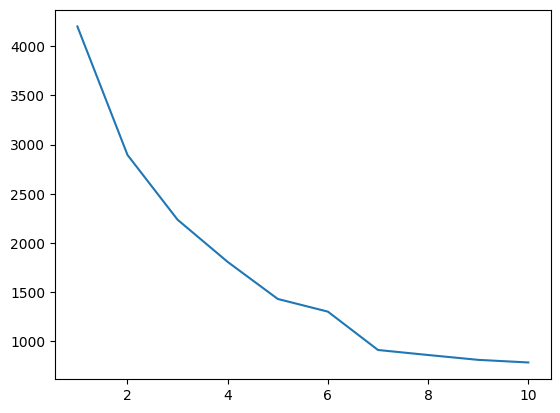

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.show()

In [ ]:
optimal_k = 7

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
print("Silhouette Score: ", silhouette_score(X_scaled, clusters))

Silhouette Score:  0.440910771033971


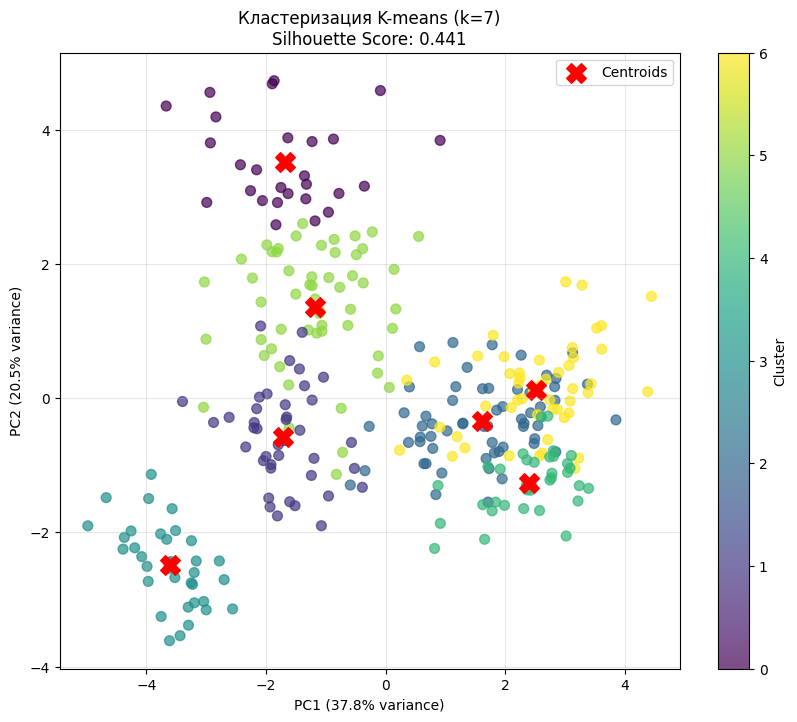

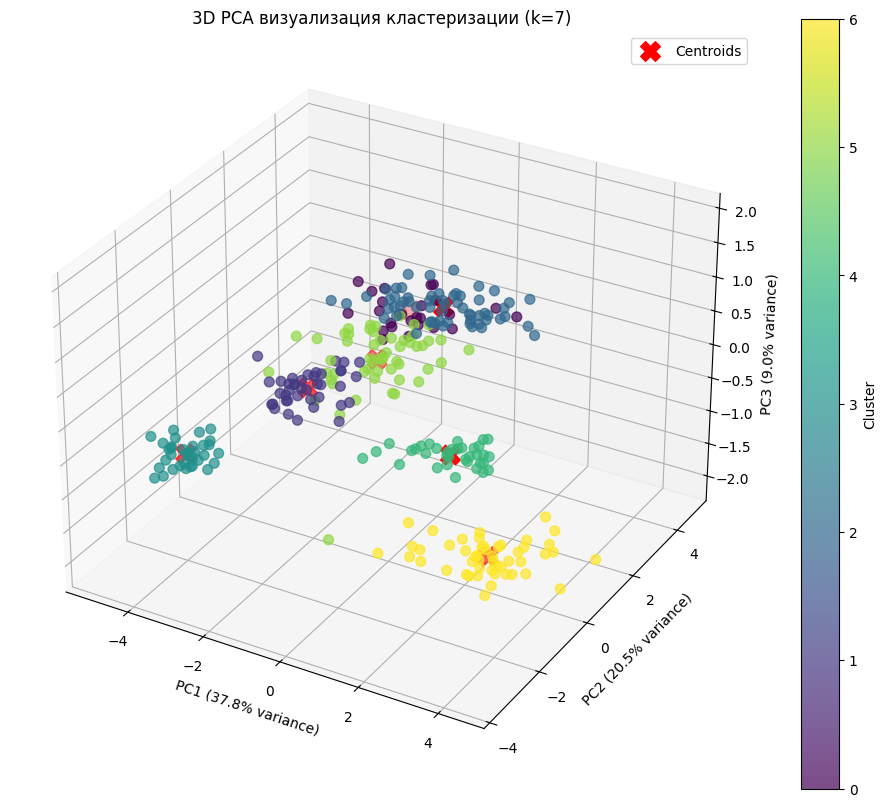

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', s=50, alpha=0.7)

centers_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', marker='X', s=200, label='Centroids')

plt.title(f'Кластеризация K-means (k={optimal_k})\nSilhouette Score: {silhouette_score(X_scaled, clusters):.3f}')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

if X_scaled.shape[1] >= 3:
    from mpl_toolkits.mplot3d import Axes3D

    pca_3d = PCA(n_components=3)
    X_pca_3d = pca_3d.fit_transform(X_scaled)

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    scatter = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
                        c=clusters, cmap='viridis', s=50, alpha=0.7)

    centers_pca_3d = pca_3d.transform(kmeans.cluster_centers_)
    ax.scatter(centers_pca_3d[:, 0], centers_pca_3d[:, 1], centers_pca_3d[:, 2],
              c='red', marker='X', s=200, label='Centroids')

    ax.set_title(f'3D PCA визуализация кластеризации (k={optimal_k})')
    ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}% variance)')
    ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}% variance)')
    ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}% variance)')
    plt.colorbar(scatter, ax=ax, label='Cluster')
    ax.legend()
    plt.show()

**Иерархическая**

In [ ]:
agg_clust = AgglomerativeClustering(n_clusters=optimal_k)
clusters = agg_clust.fit_predict(X_scaled)
print("Silhouette Score: ", silhouette_score(X_scaled, clusters))

Silhouette Score:  0.4330339415277793


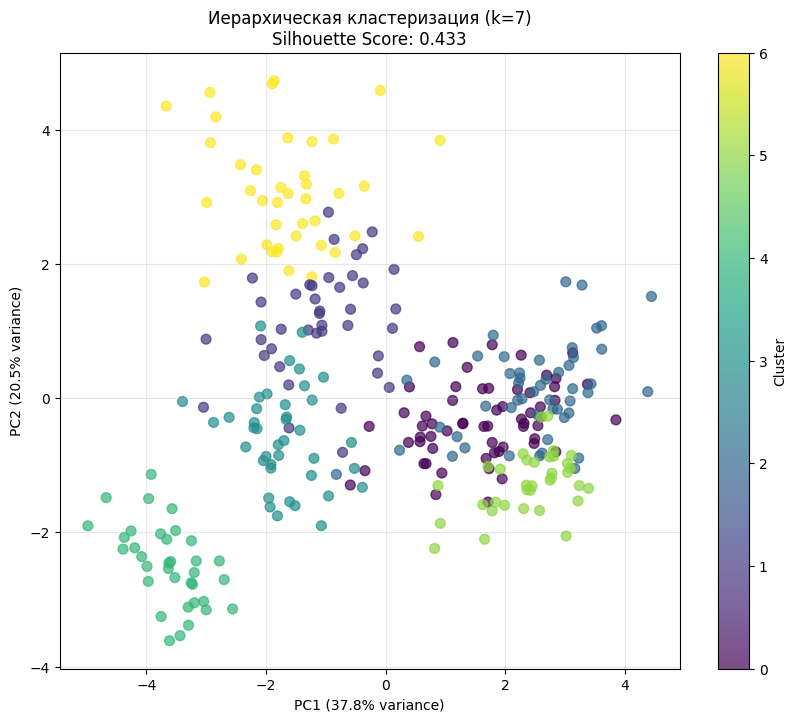

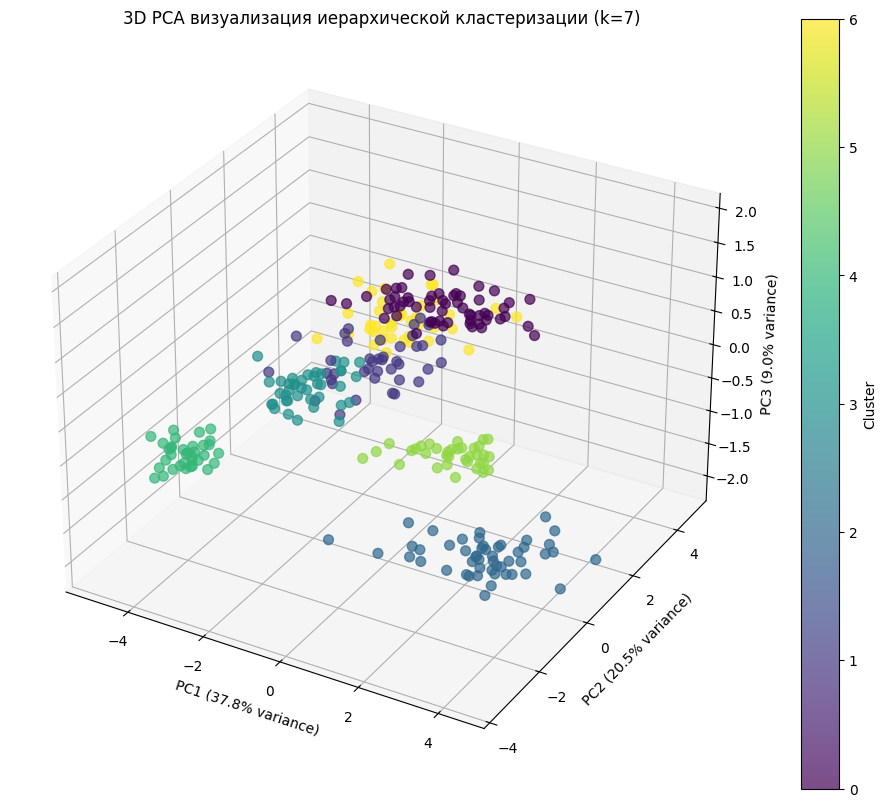

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', s=50, alpha=0.7)

plt.title(f'Иерархическая кластеризация (k={optimal_k})\nSilhouette Score: {silhouette_score(X_scaled, clusters):.3f}')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

if X_scaled.shape[1] >= 3:
    from mpl_toolkits.mplot3d import Axes3D

    pca_3d = PCA(n_components=3)
    X_pca_3d = pca_3d.fit_transform(X_scaled)

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    scatter = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
                        c=clusters, cmap='viridis', s=50, alpha=0.7)

    ax.set_title(f'3D PCA визуализация иерархической кластеризации (k={optimal_k})')
    ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}% variance)')
    ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}% variance)')
    ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}% variance)')
    plt.colorbar(scatter, ax=ax, label='Cluster')
    plt.show()

**GMM**

In [ ]:
gmm = GaussianMixture(n_components=optimal_k, random_state=42)
clusters = gmm.fit_predict(X_scaled)
print("Silhouette Score: ", silhouette_score(X_scaled, clusters))

Silhouette Score:  0.4318655773910486


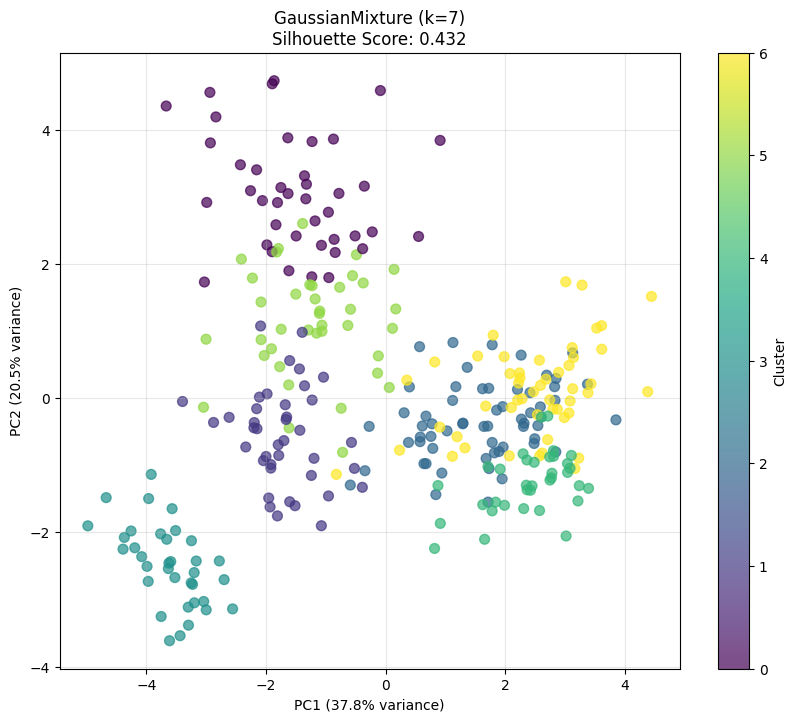

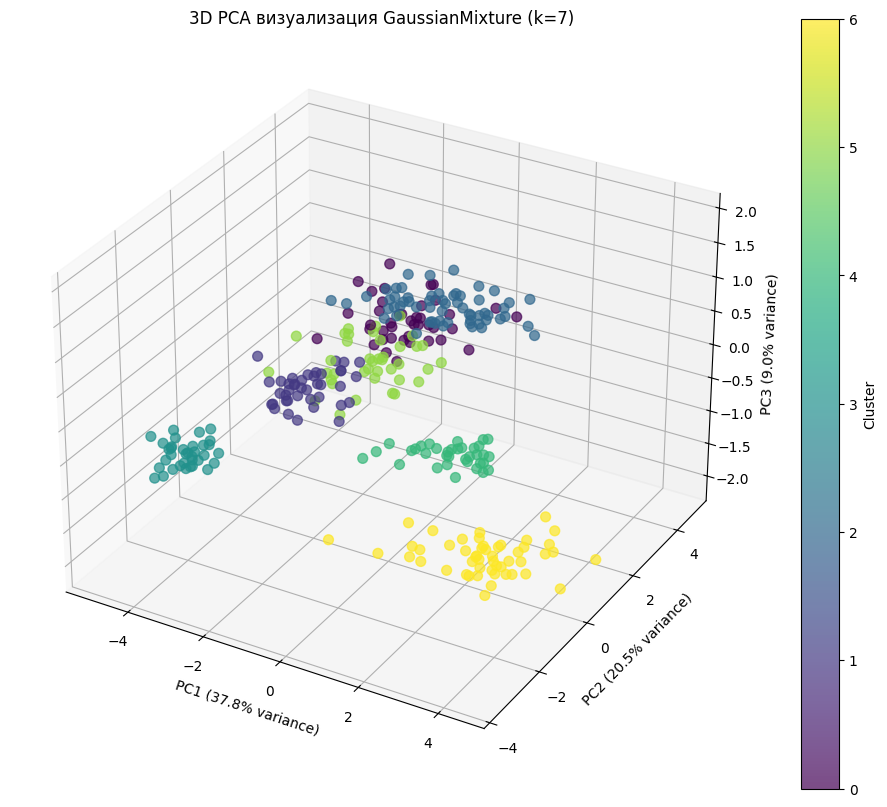

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', s=50, alpha=0.7)

plt.title(f'GaussianMixture (k={optimal_k})\nSilhouette Score: {silhouette_score(X_scaled, clusters):.3f}')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

if X_scaled.shape[1] >= 3:
    from mpl_toolkits.mplot3d import Axes3D

    pca_3d = PCA(n_components=3)
    X_pca_3d = pca_3d.fit_transform(X_scaled)

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    scatter = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
                        c=clusters, cmap='viridis', s=50, alpha=0.7)

    ax.set_title(f'3D PCA визуализация GaussianMixture (k={optimal_k})')
    ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}% variance)')
    ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}% variance)')
    ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}% variance)')
    plt.colorbar(scatter, ax=ax, label='Cluster')
    plt.show()

**Вывод:** все три алгоритма с гиперпараметрами по умолчанию показали схожие результаты (0.43-0.44).

1) KMeans (0.441) — незначительно лучший среди методов.

2) Результаты AgglomerativeClustering и GaussianMixture практически равны (0.433 и 0.432).

Значения около 0.4 указывают на слабую или умеренную структуру кластеров в данных — кластеры различимы, но не идеально разделены.

# Product quantization

Создаём синтетические эмбеддинги длинной 16 со случайным центром от 0 до 10 и белым шумом (гауссовский шум со средним 0 и стандартным отклонением 1)

In [ ]:
np.random.seed(45)

length_emb = 16
num_emb = 10000
mean = 0
std = 1

centers = np.random.randint(0, 10, (num_emb, length_emb))

noise = np.random.normal(mean, std, (num_emb, length_emb))

vectors_database = (centers + noise)

In [ ]:
vectors_database[0]

array([ 3.16810515, -1.74198437,  5.18059803,  1.6380334 ,  2.37770193,
        7.91647429,  9.28471816,  0.67709323,  6.93959557, 11.67797295,
        5.90920445,  8.52749866,  7.8114378 ,  7.98894178,  4.998913  ,
        2.04617042])

Разработаем класс product_quantization

In [ ]:
class product_quantization():
    def __init__(self, vectors_db, n_subvec, n_cluster, seed=42):
        length_emb = vectors_db.shape[1]

        if length_emb % n_subvec != 0:
            raise ValueError("Length vector embedding must be divided on number subvector whithout residual")

        self.vectors_db = vectors_db
        self.n_subvec = n_subvec
        self.n_cluster = n_cluster
        self.length_emb = length_emb
        self.length_subvec = length_emb // n_subvec
        self.codebook = np.empty((n_subvec, n_cluster, self.length_subvec))
        self.seed = seed
        self.scalers = []
        self.models = []

    def preproccesing_data(self, X):
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        self.scalers.append(scaler)
        return X_scaled

    def train(self):
        self.scalers = []

        for i in range(self.n_subvec):
            start_idx = i * self.length_subvec
            end_idx = start_idx + self.length_subvec

            X = self.preproccesing_data(self.vectors_db[:, start_idx:end_idx])

            kmeans = KMeans(n_clusters=self.n_cluster, random_state=self.seed)
            kmeans.fit(X)

            self.codebook[i] = kmeans.cluster_centers_
            self.models.append(kmeans)

    def encode(self, vectors=None):
        if vectors is None:
            vectors = self.vectors_db

        codes = []

        for i in range(self.n_subvec):
            start_idx = i * self.length_subvec
            end_idx = start_idx + self.length_subvec

            X = self.scalers[i].transform(vectors[:, start_idx:end_idx])
            kmeans = self.models[i]
            codes.append(kmeans.predict(X))

        return np.array(codes).T


    def decode(self, codes):
        reconstructed = np.zeros((codes.shape[0], self.length_emb))

        for i in range(self.n_subvec):
            start_idx = i * self.length_subvec
            end_idx = start_idx + self.length_subvec

            centroids = self.codebook[i][codes[:, i]]

            reconstructed[:, start_idx:end_idx] = self.scalers[i].inverse_transform(centroids)

        return reconstructed

    def eval(self, vectors=None):
        if vectors is None:
            vectors = self.vectors_db

        codes = self.encode(vectors)
        reconstructed = self.decode(codes)

        rmse = root_mean_squared_error(vectors, reconstructed)

        # Compression Ratio
        original_size = vectors.nbytes

        if self.n_cluster <= 256:
            dtype_size = 1  # uint8
        elif self.n_cluster <= 65536:
            dtype_size = 2  # uint16
        else:
            dtype_size = 4  # uint32

        n_vectors = vectors.shape[0]
        compressed_size = n_vectors * self.n_subvec * dtype_size

        compression_ratio = original_size / compressed_size

        #
        bits_per_original_vector = vectors.shape[1] * 32
        bits_per_code = math.ceil(math.log2(self.n_cluster))
        bits_per_compressed_vector = self.n_subvec * bits_per_code

        return {
            'rmse': rmse,
            'compression_ratio': compression_ratio,
            'bits_per_original_vector': bits_per_original_vector,
            'bits_per_compressed_vector': bits_per_compressed_vector,
            'original_size_bytes': original_size,
            'compressed_size_bytes': compressed_size
        }

    def clear(self):
        self.codebook = np.empty((self.n_subvec, self.n_cluster, self.length_subvec))
        self.scalers = []
        self.models = []

Выберем количество кластеров равное 256, потому что это соответствует uint8

In [ ]:
num_subvec = 4
num_cluster = 256

pq = product_quantization(vectors_database, num_subvec, num_cluster)

pq.train()

In [ ]:
encode_vectors = pq.encode()

In [ ]:
encode_vectors

array([[246,  35, 207,  73],
       [161,   4, 143, 208],
       [215,   7, 194, 207],
       ...,
       [ 39, 216, 233, 244],
       [122, 174,  66, 242],
       [102,  83,  67, 235]], dtype=int32)

In [ ]:
decode_vectors = pq.decode(encode_vectors)

In [ ]:
decode_vectors[0]

array([3.34536962, 0.77651066, 5.53660448, 2.10761618, 2.53448717,
       7.33544034, 9.24562623, 0.81254325, 6.67966464, 9.05551495,
       7.40861375, 8.96356004, 7.39194934, 7.85438638, 5.05928039,
       2.40993289])

In [ ]:
vectors_database[0]

array([ 3.16810515, -1.74198437,  5.18059803,  1.6380334 ,  2.37770193,
        7.91647429,  9.28471816,  0.67709323,  6.93959557, 11.67797295,
        5.90920445,  8.52749866,  7.8114378 ,  7.98894178,  4.998913  ,
        2.04617042])

In [ ]:
metrics = pq.eval()
print(f"RMSE: {metrics['rmse']:.4f}")
print(f"Compression Ratio: {metrics['compression_ratio']:.2f}:1")
print(f"Original size: {metrics['original_size_bytes'] / 1024:.2f} KB")
print(f"Compressed size: {metrics['compressed_size_bytes'] / 1024:.2f} KB")
print(f"Bits per vector: {metrics['bits_per_original_vector']} -> {metrics['bits_per_compressed_vector']}")

RMSE: 0.7949
Compression Ratio: 32.00:1
Original size: 1250.00 KB
Compressed size: 39.06 KB
Bits per vector: 512 -> 32


**Вывод:** получение значения RMSE нельзя назвать отличными, но это объясняется тем, что наши данные были синтетически сгенерированы и не имеют под собой какой-то структурной идеи, поэтому будем считать результат удовлетворительным. При этом сжатие составило 32-кратное уменьшение вектора с 1.25 МБ до 39 КБ.

Скачаем датасет SIFT1M (Доступ: https://huggingface.co/datasets/qbo-odp/sift1m/tree/main).

In [ ]:
def download_glove_100d(data_dir="data"):
    os.makedirs(data_dir, exist_ok=True)

    url = "https://nlp.stanford.edu/data/glove.6B.zip"
    zip_path = os.path.join(data_dir, "glove.6B.zip")
    txt_path = os.path.join(data_dir, "glove.6B.100d.txt")

    if not os.path.exists(txt_path):
        if not os.path.exists(zip_path):
            print("Downloading GloVe...")
            urllib.request.urlretrieve(url, zip_path)

        print("Extracting GloVe...")
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extract("glove.6B.100d.txt", path=data_dir)

    return txt_path

def load_glove_embeddings(path, max_vectors=1_000_000):
    vectors = []
    words = []

    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if i >= max_vectors:
                break

            parts = line.rstrip().split(" ")
            word = parts[0]
            vec = np.array(parts[1:], dtype=np.float32)

            words.append(word)
            vectors.append(vec)

    X = np.vstack(vectors)
    return X, words

In [ ]:
path = download_glove_100d()
X, words = load_glove_embeddings(path, max_vectors=500_000)

print("Embeddings shape:", X.shape)

pq = product_quantization(
    vectors_db=X,
    n_subvec=10,
    n_cluster=256
)

pq.train()

metrics = pq.eval()

for k, v in metrics.items():
    print(f"{k}: {v}")

Embeddings shape: (400000, 100)
rmse: 0.24536691222663426
compression_ratio: 40.0
bits_per_original_vector: 3200
bits_per_compressed_vector: 80
original_size_bytes: 160000000
compressed_size_bytes: 4000000


**Вывод:** RMSE = 0.25 - умеренная ошибка реконструкции. До сжатия, занимаемая память, 160 МБ, а после сжатия стала 4 МБ. Эффективность сжатия 40 раз.